<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Домашнее задание. Обучение языковой модели с помощью LSTM (10 баллов)

Э
В этом задании Вам предстоит обучить языковую модель с помощью рекуррентной нейронной сети. В отличие от семинарского занятия, Вам необходимо будет работать с отдельными словами, а не буквами.


Установим модуль ```datasets```, чтобы нам проще было работать с данными.

In [ ]:
# !pip install datasets

Импорт необходимых библиотек

In [43]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List

import seaborn
seaborn.set(palette='summer')

import re

In [2]:
# nltk.download('punkt')
nltk.download('punkt_tab', download_dir='nltk_data')
nltk.data.path.insert(0, 'nltk_data')

[nltk_data] Downloading package punkt_tab to nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
d:\DLS\.venv\Lib\site-packages\nltk\downloader.py:2395: RuntimeWarning: Security Warning [pathsec.ZipFile]: Path D:\DLS\Sem_2\Language_modeling\nltk_data\tokenizers\punkt_tab.zip allowed via CWD.
  zf = ZipFile(filename)


In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных

Воспользуемся датасетом imdb. В нем хранятся отзывы о фильмах с сайта imdb. Загрузим данные с помощью функции ```load_dataset```

In [ ]:
# Загрузим датасет
dataset = load_dataset('imdb')

### Препроцессинг данных и создание словаря (1 балл)

Далее вам необходмо самостоятельно произвести препроцессинг данных и получить словарь или же просто ```set``` строк. Что необходимо сделать:

1. Разделить отдельные тренировочные примеры на отдельные предложения с помощью функции ```sent_tokenize``` из бибилиотеки ```nltk```. Каждое отдельное предложение будет одним тренировочным примером.
2. Оставить только те предложения, в которых меньше ```word_threshold``` слов.
3. Посчитать частоту вхождения каждого слова в оставшихся предложениях. Для деления предлоения на отдельные слова удобно использовать функцию ```word_tokenize```.
4. Создать объект ```vocab``` класса ```set```, положить в него служебные токены '\<unk\>', '\<bos\>', '\<eos\>', '\<pad\>' и vocab_size самых частовстречающихся слов.   

In [5]:
dataset['train']['text'][0]

'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between, ev

In [ ]:
sentences = []
word_threshold = 32

# Получить отдельные предложения и поместить их в sentences
for text in tqdm(dataset['train']['text']):
    text = re.sub(r'<br\s*/?>',' ',text)
    text = re.sub(r'\s+',' ',text)
    sents = sent_tokenize(text)
    for sent in sents:
        words = word_tokenize(sent)
        if len(words) < word_threshold:
            sentences.append(sent.lower())

In [8]:
sentences[2]

'in between asking politicians and ordinary denizens of stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.'

In [9]:
print("Всего предложений:", len(sentences))

Всего предложений: 254304


Посчитаем для каждого слова его встречаемость.

In [ ]:
words = Counter()

# Расчет встречаемости слов
for token in tqdm(sentences):
    words_tokens = word_tokenize(token)
    for word in words_tokens:
        words[word] += 1

In [11]:
len(words)

75982

In [12]:
words['i']

61625

Добавим в словарь ```vocab_size``` самых встречающихся слов.

In [13]:
vocab = set()
vocab_size = 40000

# Наполнение словаря
words_sorted = words.most_common(vocab_size)
vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
for word in words_sorted:
    vocab.add(word[0])

In [14]:
assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

In [15]:
print("Всего слов в словаре:", len(vocab))

Всего слов в словаре: 40004


### Подготовка датасета (1 балл)

Далее, как и в семинарском занятии, подготовим датасеты и даталоадеры.

В классе ```WordDataset``` вам необходимо реализовать метод ```__getitem__```, который будет возвращать сэмпл данных по входному idx, то есть список целых чисел (индексов слов).

Внутри этого метода необходимо добавить служебные токены начала и конца последовательности, а также токенизировать соответствующее предложение с помощью ```word_tokenize``` и сопоставить ему индексы из ```word2ind```.

In [16]:
word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

In [18]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        tokenized_sentence = []

        processed_sent = self.data[idx].lower()
        tokenized_sentence.append(self.bos_id)
        tokenized_sentence += [
            word2ind.get(word, self.unk_id) for word in word_tokenize(processed_sent)
            ]
        tokenized_sentence += [self.eos_id]
        return tokenized_sentence

    def __len__(self) -> int:
        return len(self.data)

In [20]:
check_dataset = WordDataset(dataset['train']['text'])
print("Начало первого текста:",dataset['train'][0]['text'][:33])
print("Первые 7 слов первого текста после обработки:",check_dataset[0][:7])
print("Слова по индексам из словаря ind2word:", ind2word[30330], ind2word[20562], ind2word[21133], ind2word[20562], ind2word[12161], ind2word[16044], ind2word[9270])

Начало первого текста: I rented I AM CURIOUS-YELLOW from
Первые 7 слов первого текста после обработки: [30330, 20562, 21133, 20562, 12161, 16044, 9270]
Слова по индексам из словаря ind2word: <bos> i rented i am curious-yellow from


In [21]:
def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> torch.Tensor:
    seq_lens = [len(x) for x in input_batch]
    max_seq_len = max(seq_lens)

    new_batch = []
    for sequence in input_batch:
        for _ in range(max_seq_len - len(sequence)):
            sequence.append(pad_id)
        new_batch.append(sequence)

    sequences = torch.LongTensor(new_batch).to(device)

    new_batch = {
        'input_ids': sequences[:,:-1],
        'target_ids': sequences[:,1:]
    }

    return new_batch

In [22]:
train_sentences, eval_sentences = train_test_split(sentences, test_size=0.2)
eval_sentences, test_sentences = train_test_split(sentences, test_size=0.5)

train_dataset = WordDataset(train_sentences)
eval_dataset = WordDataset(eval_sentences)
test_dataset = WordDataset(test_sentences)

batch_size = 128

train_dataloader = DataLoader(
    train_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

test_dataloader = DataLoader(
    test_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

In [23]:
print(next(iter(train_dataloader))['input_ids'].shape)
print(next(iter(train_dataloader))['input_ids'])
print(next(iter(train_dataloader))['target_ids'])

torch.Size([128, 32])
tensor([[30330, 24337, 36777,  ..., 32813, 32813, 32813],
        [30330,  1634, 37621,  ..., 30949, 13203, 32813],
        [30330, 11208, 37257,  ..., 32813, 32813, 32813],
        ...,
        [30330, 35978, 26381,  ..., 32813, 32813, 32813],
        [30330, 24337,  3477,  ..., 32813, 32813, 32813],
        [30330,  6847, 22258,  ..., 32813, 32813, 32813]], device='cuda:0')
tensor([[24337, 36777, 32682,  ..., 32813, 32813, 32813],
        [ 1634, 37621, 17766,  ..., 13203, 32813, 32813],
        [11208, 37257,  2327,  ..., 32813, 32813, 32813],
        ...,
        [35978, 26381,   727,  ..., 32813, 32813, 32813],
        [24337,  3477,  1022,  ..., 32813, 32813, 32813],
        [ 6847, 22258, 16274,  ..., 32813, 32813, 32813]], device='cuda:0')


## Обучение и архитектура модели

Вам необходимо на практике проверить, что влияет на качество языковых моделей. В этом задании нужно провести серию экспериментов с различными вариантами языковых моделей и сравнить различия в конечной перплексии на тестовом множестве.

Возмоэные идеи для экспериментов:

* Различные RNN-блоки, например, LSTM или GRU. Также можно добавить сразу несколько RNN блоков друг над другом с помощью аргумента num_layers. Вам поможет официальная документация [здесь](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
* Различные размеры скрытого состояния. Различное количество линейных слоев после RNN-блока. Различные функции активации.
* Добавление нормализаций в виде Dropout, BatchNorm или LayerNorm
* Различные аргументы для оптимизации, например, подбор оптимального learning rate или тип алгоритма оптимизации SGD, Adam, RMSProp и другие
* Любые другие идеи и подходы

После проведения экспериментов необходимо составить таблицу результатов, в которой описан каждый эксперимент и посчитана перплексия на тестовом множестве.

Учтите, что эксперименты, которые различаются, например, только размером скрытого состояния или количеством линейных слоев считаются, как один эксперимент.

Успехов!

### Функция evaluate (1 балл)

Заполните функцию ```evaluate```

In [25]:
def evaluate(model, criterion, dataloader) -> float:
    model.eval()
    losses=[]
    with torch.no_grad():
        for batch in dataloader:
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1) # Посчитайте логиты предсказаний следующих слов
            loss = criterion(logits, batch['target_ids'].flatten())
            losses.append(loss.item())

    # исправлено в исходном кода для корректного расчета метрики, средний loss по всем батчам, затем exp
    average_loss = sum(losses) / len(losses)
    perplexity = torch.exp(torch.tensor(average_loss))

    return perplexity.item()

### Train loop (1 балл)

Напишите функцию для обучения модели.

In [26]:
def train_model(model_class, hidden_dim, num_epoch):
    # Напишите код здесь
    losses = []
    perplexities = []

    model = model_class(hidden_dim=hidden_dim, vocab_size=len(vocab)).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters())

    for epoch in range(num_epoch):
        epoch_losses = []
        model.train()
        for batch in tqdm(train_dataloader, desc=f'Training epoch {epoch}:'):
            optimizer.zero_grad()
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
            loss = criterion(
                logits, batch['target_ids'].flatten())
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

        losses.append(sum(epoch_losses) / len(epoch_losses))
        perplexities.append(evaluate(model, criterion, eval_dataloader))
    return model, losses, perplexities

### Первый эксперимент (2 балла)

Определите архитектуру модели и обучите её.

В данном эксперименте обучим модель, представленную в семинаре с реккурентным слоем GRU и размером скрытого состояния 128.

In [27]:
class LanguageModel(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        # Опишите свою нейронную сеть здесь
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        # А тут опишите forward pass модели
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]
        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, seq_len, hidden_dim]
        projection = self.projection(self.non_lin(output))  # [batch_size, seq_len, vocab_size]
        return projection

In [ ]:
# Обучите модель здесь
model_LanguageModel, losses_LanguageModel, perplex_LanguageModel = train_model(model_class=LanguageModel, hidden_dim=128, num_epoch=10)

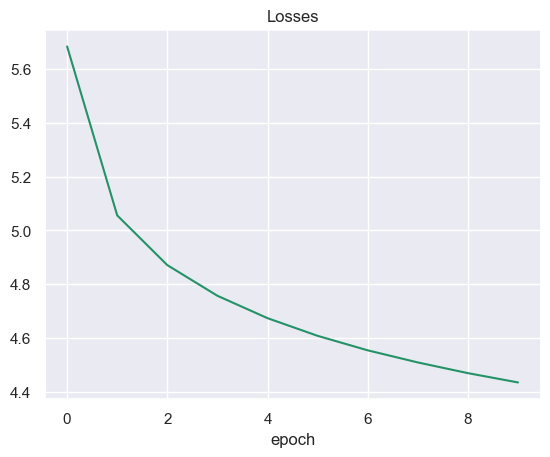

In [29]:
plt.plot(np.arange(len(losses_LanguageModel)), losses_LanguageModel)
plt.title('Losses')
plt.xlabel("epoch")
plt.show()

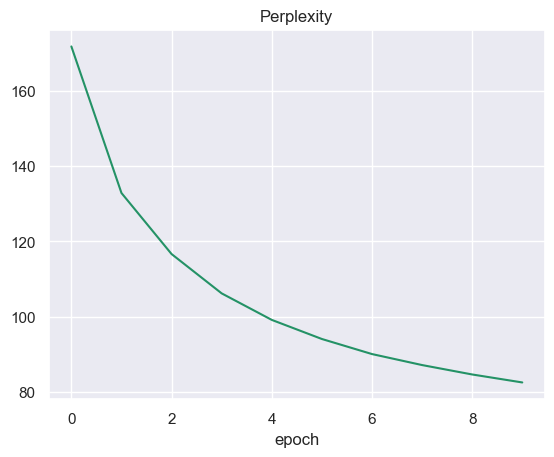

In [30]:
plt.plot(np.arange(len(perplex_LanguageModel)), perplex_LanguageModel)
plt.title('Perplexity')
plt.xlabel("epoch")
plt.show()

In [31]:
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])

print("Perplexity на валидационых данных:", min(perplex_LanguageModel))

perplex_LanguageModel_test = evaluate(model_LanguageModel, criterion, test_dataloader)
print("Perplexity на тестовых данных:", perplex_LanguageModel_test)

Perplexity на валидационых данных: 82.53703308105469
Perplexity на тестовых данных: 82.57124328613281


### Второй эксперимент (2 балла)

Попробуйте что-то поменять в модели или в пайплайне обучения, идеи для экспериментов можно подсмотреть выше.

Заменим архитектуру реккурентного слоя на LSTM, размер скрытого состояния оставим прежним.

In [32]:
# Проведите второй эксперимент
class LanguageModel_LSTM(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        # Опишите свою нейронную сеть здесь
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)

        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        # А тут опишите forward pass модели
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]
        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, seq_len, hidden_dim]
        projection = self.projection(self.non_lin(output))  # [batch_size, seq_len, vocab_size]
        return projection

In [ ]:
model_LanguageModel_LSTM, losses_LanguageModel_LSTM, perplex_LanguageModel_LSTM = train_model(model_class=LanguageModel_LSTM, hidden_dim=128, num_epoch=10)

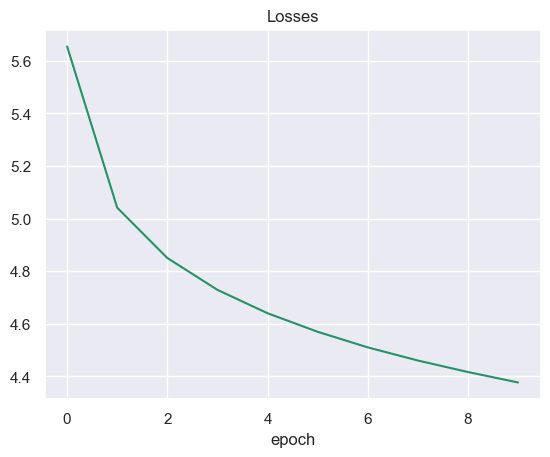

In [34]:
plt.plot(np.arange(len(losses_LanguageModel_LSTM)), losses_LanguageModel_LSTM)
plt.title('Losses')
plt.xlabel("epoch")
plt.show()

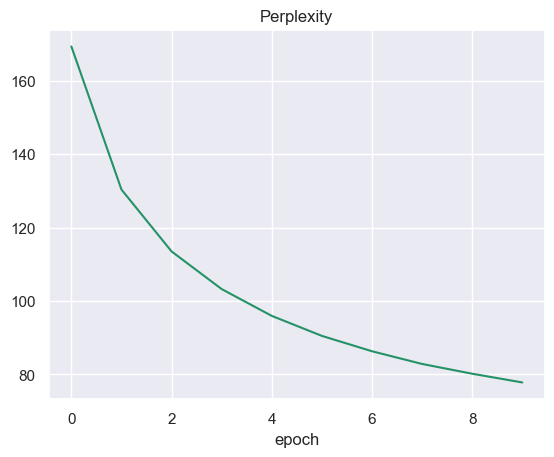

In [35]:
plt.plot(np.arange(len(perplex_LanguageModel_LSTM)), perplex_LanguageModel_LSTM)
plt.title('Perplexity')
plt.xlabel("epoch")
plt.show()

In [36]:
print("Perplexity на валидационых данных:", min(perplex_LanguageModel_LSTM))

perplex_LanguageModel_LSTM_test = evaluate(model_LanguageModel_LSTM, criterion, test_dataloader)
print("Perplexity на тестовых данных:", perplex_LanguageModel_LSTM_test)

Perplexity на валидационых данных: 77.78447723388672
Perplexity на тестовых данных: 77.68177032470703


- Изменим размер скрытого состояния на 256 и обучим модель.

In [ ]:
model_LanguageModel_LSTM_double_hd, losses_LanguageModel_LSTM_double_hd, perplex_LanguageModel_LSTM_double_hd = train_model(model_class=LanguageModel_LSTM, hidden_dim=256, num_epoch=10)

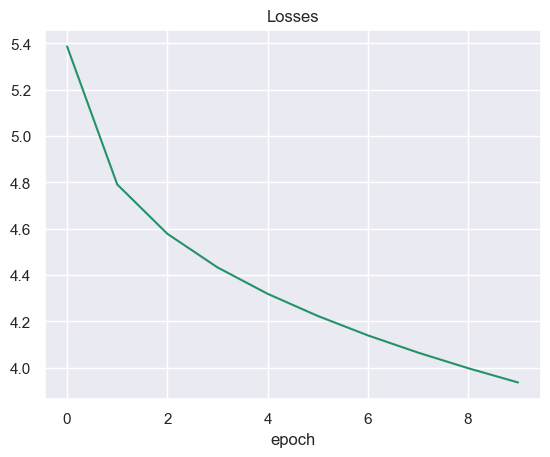

In [38]:
plt.plot(np.arange(len(losses_LanguageModel_LSTM_double_hd)), losses_LanguageModel_LSTM_double_hd)
plt.title('Losses')
plt.xlabel("epoch")
plt.show()

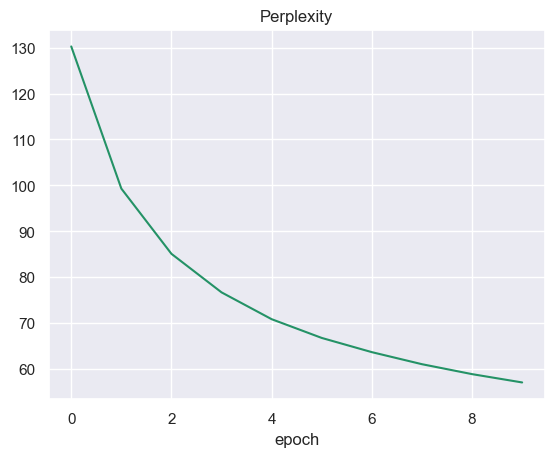

In [39]:
plt.plot(np.arange(len(perplex_LanguageModel_LSTM_double_hd)), perplex_LanguageModel_LSTM_double_hd)
plt.title('Perplexity')
plt.xlabel("epoch")
plt.show()

In [40]:
print("Perplexity на валидационых данных:", min(perplex_LanguageModel_LSTM_double_hd))

perplex_LanguageModel_LSTM_double_hd_test = evaluate(model_LanguageModel_LSTM_double_hd, criterion, test_dataloader)
print("Perplexity на тестовых данных:", perplex_LanguageModel_LSTM_double_hd_test)

Perplexity на валидационых данных: 57.045433044433594
Perplexity на тестовых данных: 57.012638092041016


Лучшую метрику на тестовых данных показала модель LSTM (с hidden_dim = 256): (Perplexity = 57.01).

Попробуем сгенерировать текст при помощи данной языковой модели.

In [41]:
def generate_sequence(model, starting_seq: str, max_seq_len: int = 32):
    top_k=10
    device = 'cpu'
    model = model.to(device)
    starting_words = starting_seq.split()
    input_ids = [word2ind['<bos>']] + [word2ind.get(word, word2ind['<unk>']) for word in starting_words]
    input_ids = torch.LongTensor(input_ids).to(device)

    model.eval()
    with torch.no_grad():
        for i in range(max_seq_len):
            logits = model(input_ids.unsqueeze(0))
            next_word_logits = logits[0, -1, :]
            top_logits, top_indices = torch.topk(logits, top_k)
            probabilities = F.softmax(top_logits, dim=-1)
            next_word_id = next_word_logits.argmax().item()

            next_word_tensor = torch.tensor([next_word_id], device=device)
            input_ids = torch.cat([input_ids, next_word_tensor])

            if next_word_id == word2ind['<eos>']:
                break
    generated_words = [ind2word[idx.item()] for idx in input_ids]
    sentences = ' '.join(generated_words)

    return sentences

In [44]:
generate_sequence(model_LanguageModel_LSTM_double_hd, starting_seq='i watched')

'<bos> i watched this movie and i was very disappointed . <eos>'

### Отчет (2 балла)

Опишите проведенные эксперименты. Сравните перплексии полученных моделей. Предложите идеи по улучшению качества моделей.

В процессе работы были проведены следующие экперименты:
- использование реккурентного слоя GRU (hidden_dim = 128)
- использование реккурентного слоя LSTM (hidden_dim = 128)
- использование реккурентного слоя LSTM (hidden_dim = 256)

Лучшую метрику показала модель LSTM (с hidden_dim = 256): (Perplexity = 58.01). Текст, генерируемый данной языковой моделью не лишен смысла.
Для улучшения метрики необходимо продолжить эксперименты с изменениями архитектуры модели и ее параметров: применение других архитектур слоев, их количества, применение других функций активации и тд.